In [1]:
# 01 입찰공고 입찰결과 병합 후 사업유형 장착

In [ ]:
from pathlib import Path
import pandas as pd


# 1. 현재 스크립트 파일이 위치한 폴더를 기준으로 기본 경로 설정
BASE_DIR = Path(__file__).resolve().parent

# 2. 지정해주신 디렉토리 구조(data/raw/)에 맞게 파일 경로 설정
DATA_DIR = BASE_DIR / 'data' / 'raw'

notice_path = DATA_DIR / 'bid_notice_20210101_20251231.csv'
result_path = DATA_DIR / 'bid_result_20210101_20251231.csv'

# 결과물은 프로젝트 루트 또는 output 폴더에 저장 (여기서는 프로젝트 루트로 설정)
output_path = BASE_DIR / 'bid_master_2021_2025.csv'

print('📂 입찰공고 및 입찰결과 원본 파일 로드 중...')
df_notice = pd.read_csv(notice_path, encoding='utf-8-sig')
df_result = pd.read_csv(result_path, encoding='utf-8-sig')

# 컬럼명 앞뒤 공백 제거
df_notice.columns = df_notice.columns.str.strip()
df_result.columns = df_result.columns.str.strip()

print(f'  - 공고 원본 파일 건수: {len(df_notice):,}건')
print(f'  - 입찰 결과 파일 건수: {len(df_result):,}건')

# 3. 공통 키 설정
merge_keys = ['pblancNo', 'pblancOdr']

# 4. 공고 원본에서 필요한 컬럼만 추출 후 중복 제거
notice_subset = df_notice[['pblancNo', 'pblancOdr', 'busiDivs']].drop_duplicates(subset=merge_keys)

print('\n🔗 공고번호 기준으로 데이터 병합(Merge) 진행 중...')
df_master = pd.merge(df_result, notice_subset, on=merge_keys, how='inner')

# 5. 유찰 여부(fail_yn) 라벨 생성
df_master['fail_yn'] = df_master['bidResult'].astype(str).str.contains('유찰').astype(int)

# 6. 연도 컬럼 추출
if 'opengDate' in df_master.columns:
    df_master['year'] = df_master['opengDate'].astype(str).str[:4].astype(int)
elif 'demandYear' in df_master.columns:
    df_master['year'] = df_master['demandYear']

print(f'✨ 병합 및 정제 완료된 마스터 데이터 총 건수: {len(df_master):,}건')
print(f"  - 사업유형이 성공적으로 장착된 건수: {df_master['busiDivs'].notnull().sum():,}건")

# 7. 최종 통합 마스터 파일 저장
df_master.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'🚀 통합 마스터 파일 저장 완료!\n📁 저장 경로: {output_path}')

NameError: name '__file__' is not defined

In [2]:
import pandas as pd

# 1. 파일 경로 설정 (본인 PC에 있는 실제 원본 파일명과 경로로 수정해주세요)
notice_path = (
    r'C:\Users\user\Desktop\python\project_1\bid_notice_20210101_20251231.csv'
)  # 입찰공고 원본 파일 (사업유형 포함)
result_path = (
    r'C:\Users\user\Desktop\python\project_1\bid_result_20210101_20251231.csv'
)  # 입찰결과 파일 (유찰 여부 포함)
output_path = (
    r'C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv'
)

print('📂 입찰공고 및 입찰결과 원본 파일 로드 중...')
df_notice = pd.read_csv(notice_path, encoding='utf-8-sig')
df_result = pd.read_csv(result_path, encoding='utf-8-sig')

# 컬럼명 앞뒤 공백 제거
df_notice.columns = df_notice.columns.str.strip()
df_result.columns = df_result.columns.str.strip()

print(f'  - 공고 원본 파일 건수: {len(df_notice):,}건')
print(f'  - 입찰 결과 파일 건수: {len(df_result):,}건')

# 2. 공통 키 설정 (나라장터 데이터는 보통 공고번호와 차수가 쌍을 이룹니다)
# 만약 차수 컬럼명이 다르거나 공고번호만으로 매칭해야 한다면 키를 조정하세요 (예: ['pblancNo'])
merge_keys = ['pblancNo', 'pblancOdr']

# 3. 공고 원본에서 필요한 컬럼(공고번호, 차수, 사업유형 등)만 추출 후 중복 제거
# (사업유형 컬럼명이 'busiDivs'가 아니라면 실제 컬럼명으로 변경해주세요. 예: 'pblancSe' 등)
notice_subset = df_notice[
    ['pblancNo', 'pblancOdr', 'busiDivs']
].drop_duplicates(subset=merge_keys)

print('\n🔗 공고번호 기준으로 데이터 병합(Merge) 진행 중...')
df_master = pd.merge(df_result, notice_subset, on=merge_keys, how='inner')

# 4. 유찰 여부(fail_yn) 라벨 생성 (개찰결과에서 '유찰' 키워드 포함 여부 확인)
df_master['fail_yn'] = (
    df_master['bidResult'].astype(str).str.contains('유찰').astype(int)
)

# 5. 연도 컬럼 추출 (개찰일 'opengDate' 또는 공고일 기준)
if 'opengDate' in df_master.columns:
    df_master['year'] = (
        df_master['opengDate'].astype(str).str[:4].astype(int)
    )
elif 'demandYear' in df_master.columns:
    df_master['year'] = df_master['demandYear']

print(f'✨ 병합 및 정제 완료된 마스터 데이터 총 건수: {len(df_master):,}건')
print(
    '  - 사업유형이 성공적으로 장착된 건수:'
    f" {df_master['busiDivs'].notnull().sum():,}건"
)

# 6. 최종 통합 마스터 파일 저장
df_master.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'🚀 통합 마스터 파일 저장 완료!\n📁 저장 경로: {output_path}')

📂 입찰공고 및 입찰결과 원본 파일 로드 중...
  - 공고 원본 파일 건수: 61,142건
  - 입찰 결과 파일 건수: 38,114건

🔗 공고번호 기준으로 데이터 병합(Merge) 진행 중...
✨ 병합 및 정제 완료된 마스터 데이터 총 건수: 38,114건
  - 사업유형이 성공적으로 장착된 건수: 38,114건
🚀 통합 마스터 파일 저장 완료!
📁 저장 경로: C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv


In [ ]:
# 조합 룩업테이블 만들기 + 10개 미만 합침

In [13]:
import pandas as pd

# 1. 마스터 파일 경로 설정
master_path = r'C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv'
output_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv'

print('📂 통합 마스터 파일 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')

# 2. 발주기관 그룹 매핑 함수 (공군 계열 명확히 추가!)
def map_org_group(val):
    val_str = str(val)
    if '육군' in val_str or '3군단' in val_str or '군단' in val_str or '사령부' in val_str:
        return '1. 육군계열'
    elif '공군' in val_str:
        return '2. 공군계열'  # 👈 공군 계열 명확히 분리
    elif '해군' in val_str or '해병대' in val_str:
        return '3. 해군/해병대계열'
    elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
        return '4. 국방부직할/합동'
    else:
        return '기타계열'

df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# 3. 학습 기간 설정: 2021년 ~ 2024년 데이터만 필터링
print("🔍 2021~2024년 과거 학습 데이터 추출 및 조합 집계 중...")
df_train = df_master[(df_master['year'] >= 2021) & (df_master['year'] <= 2024)].copy()

# 4. 3가지 기준(org_group, mthd_group, busiDivs)으로 초기 룩업 테이블 생성
df = df_train.groupby(['org_group', 'mthd_group', 'busiDivs']).agg(
    sample_count=('fail_yn', 'count'),
    fail_rate=('fail_yn', 'mean')
).reset_index()

# 정밀 가중평균 계산을 위한 유찰 건수 복원
df['fail_count'] = df['sample_count'] * df['fail_rate']

# 5. 데이터 분리: 10개 이상(기준 테이블) vs 10개 미만(합산 대상 소표본)
large_df = df[df['sample_count'] >= 10].copy().reset_index(drop=True)
small_df = df[df['sample_count'] < 10].copy().reset_index(drop=True)

print(f'✨ 기준 유지 데이터 (10건 이상): {len(large_df):,}개 행')
print(f'➕ 흡수시킬 소표본 데이터 (10건 미만): {len(small_df):,}개 행\n')

# 6. 소표본 행들을 우선순위에 따라 10개 이상 행들에 흡수시키기
print("🔄 소표본 데이터 상위 그룹 흡수(Absorption) 작업 중...")
for idx, row in small_df.iterrows():
    org = row['org_group']
    mthd = row['mthd_group']
    busi = row['busiDivs']
    s_cnt = row['sample_count']
    f_cnt = row['fail_count']

    matched = False

    # [1순위] 기관 + 계약방식이 일치하는 10개 이상 행 찾기
    cand1 = large_df[
        (large_df['org_group'] == org) & (large_df['mthd_group'] == mthd)
    ]
    if not cand1.empty:
        target_idx = cand1['sample_count'].idxmax()
        large_df.loc[target_idx, 'sample_count'] += s_cnt
        large_df.loc[target_idx, 'fail_count'] += f_cnt
        matched = True
    else:
        # [2순위] 기관 + 사업유형이 일치하는 10개 이상 행 찾기
        cand2 = large_df[
            (large_df['org_group'] == org) & (large_df['busiDivs'] == busi)
        ]
        if not cand2.empty:
            target_idx = cand2['sample_count'].idxmax()
            large_df.loc[target_idx, 'sample_count'] += s_cnt
            large_df.loc[target_idx, 'fail_count'] += f_cnt
            matched = True

    # [안전장치] 만약 1, 2순위 모두 못 찾았다면 해당 기관의 가장 큰 그룹에 흡수
    if not matched:
        cand3 = large_df[large_df['org_group'] == org]
        if not cand3.empty:
            target_idx = cand3['sample_count'].idxmax()
            large_df.loc[target_idx, 'sample_count'] += s_cnt
            large_df.loc[target_idx, 'fail_count'] += f_cnt

# 7. 흡수 완료 후 유찰률(fail_rate) 재계산 및 포맷팅
large_df['fail_rate'] = large_df['fail_count'] / large_df['sample_count']
large_df['fail_rate_pct'] = (large_df['fail_rate'] * 100).round(2).astype(str) + '%'

# 8. 최종 결과 저장
large_df[[
    'org_group',
    'mthd_group',
    'busiDivs',
    'sample_count',
    'fail_rate',
    'fail_rate_pct',
]].to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'🚀 공군 포함 및 소표본 흡수 완료된 최종 룩업 테이블 저장 완료!')
print(f'📁 저장 경로: {output_path}')

# 기관별 분포 확인용 샘플 출력
print("\n📊 [생성된 룩업 테이블 내 기관별 분포 요약]")
print(large_df['org_group'].value_counts())

📂 통합 마스터 파일 로드 중...
🔍 2021~2024년 과거 학습 데이터 추출 및 조합 집계 중...
✨ 기준 유지 데이터 (10건 이상): 46개 행
➕ 흡수시킬 소표본 데이터 (10건 미만): 21개 행

🔄 소표본 데이터 상위 그룹 흡수(Absorption) 작업 중...
🚀 공군 포함 및 소표본 흡수 완료된 최종 룩업 테이블 저장 완료!
📁 저장 경로: C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv

📊 [생성된 룩업 테이블 내 기관별 분포 요약]
org_group
기타계열           14
1. 육군계열        11
2. 공군계열         9
3. 해군/해병대계열     6
4. 국방부직할/합동     6
Name: count, dtype: int64


In [3]:
import pandas as pd

# 1. 파일 경로 설정 (오늘 지정해주신 경로)
master_path = r'C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv'
lookup_output_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_2021_2024.csv'

print('📂 통합 마스터 파일 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')

# 2. 발주기관(ornt)을 상위 그룹(org_group)으로 묶어주는 매핑 함수 정의
def map_org_group(val):
    val_str = str(val)
    if '육군' in val_str or '3군단' in val_str or '군단' in val_str or '사령부' in val_str:
        return '1. 육군계열'
    elif '해군' in val_str or '해병대' in val_str:
        return '3. 해군/해병대계열'
    elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
        return '4. 국방부직할/합동'
    else:
        return '기타계열'

df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth'] # 계약방식 컬럼

# 3. 학습 기간 설정: 2021년 ~ 2024년 데이터만 필터링
print("🔍 2021~2024년 과거 학습 데이터 추출 및 룩업 테이블 생성 중...")
df_train = df_master[(df_master['year'] >= 2021) & (df_master['year'] <= 2024)].copy()

# 4. 3가지 기준(org_group, mthd_group, busiDivs)으로 그룹화하여 유찰률 계산
lookup_table = df_train.groupby(['org_group', 'mthd_group', 'busiDivs']).agg(
    sample_count=('fail_yn', 'count'), # 총 공고 수
    fail_count=('fail_yn', 'sum')      # 실제 유찰 수
).reset_index()

# 과거 유찰률 산출
lookup_table['fail_rate'] = lookup_table['fail_count'] / lookup_table['sample_count']

# 데이터 정렬 (공고 수가 많고 유찰률이 높은 순서)
lookup_table = lookup_table.sort_values(by=['sample_count', 'fail_rate'], ascending=[False, False])

print(f"✨ 룩업 테이블 생성 완료! (총 조합 수: {len(lookup_table):,}개)")

# 5. 룩업 테이블 파일로 저장
lookup_table.to_csv(lookup_output_path, index=False, encoding='utf-8-sig')
print(f"🚀 룩업 테이블 저장 완료!\n📁 저장 경로: {lookup_output_path}")

# 상위 5개 샘플 미리보기
print("\n📊 [생성된 룩업 테이블 상위 5개 샘플]")
print(lookup_table.head())

📂 통합 마스터 파일 로드 중...
🔍 2021~2024년 과거 학습 데이터 추출 및 룩업 테이블 생성 중...
✨ 룩업 테이블 생성 완료! (총 조합 수: 55개)
🚀 룩업 테이블 저장 완료!
📁 저장 경로: C:\Users\user\Desktop\python\project_1\risk_lookup_table_2021_2024.csv

📊 [생성된 룩업 테이블 상위 5개 샘플]
   org_group mthd_group busiDivs  sample_count  fail_count  fail_rate
8    1. 육군계열       제한경쟁       물품         10596        2155   0.203379
47      기타계열       제한경쟁       물품          5067         666   0.131439
45      기타계열       일반경쟁       물품          3265         442   0.135375
48      기타계열       제한경쟁       용역          1801         248   0.137701
6    1. 육군계열       일반경쟁       물품          1749         364   0.208119


In [ ]:
# 룩업테이블 다듬기
# 10개 미만인 것들 다른곳에 통합

In [7]:
import pandas as pd

# 1. 2021~2024년 룩업 테이블 데이터 로드 (경로 반영)
file_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_2021_2024.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 정밀 가중평균 계산을 위한 유찰 건수 복원
df['fail_count'] = df['sample_count'] * df['fail_rate']

# 2. 데이터 분리: 10개 이상(기준 테이블) vs 10개 미만(합산 대상 소표본)
large_df = df[df['sample_count'] >= 10].copy().reset_index(drop=True)
small_df = df[df['sample_count'] < 10].copy().reset_index(drop=True)

print(f'✨ 기준 유지 데이터 (10건 이상): {len(large_df):,}개 행')
print(f'➕ 흡수시킬 소표본 데이터 (10건 미만): {len(small_df):,}개 행\n')

# 3. 소표본 행들을 우선순위에 따라 10개 이상 행들에 흡수시키기
for idx, row in small_df.iterrows():
    org = row['org_group']
    mthd = row['mthd_group']
    busi = row['busiDivs']
    s_cnt = row['sample_count']
    f_cnt = row['fail_count']

    matched = False

    # [1순위] 기관 + 계약방식이 일치하는 10개 이상 행 찾기
    cand1 = large_df[
        (large_df['org_group'] == org) & (large_df['mthd_group'] == mthd)
    ]
    if not cand1.empty:
        # 일치하는 행이 여러 개면 표본이 가장 큰 대표 행에 합산
        target_idx = cand1['sample_count'].idxmax()
        large_df.loc[target_idx, 'sample_count'] += s_cnt
        large_df.loc[target_idx, 'fail_count'] += f_cnt
        matched = True
    else:
        # [2순위] 기관 + 사업유형(품목)이 일치하는 10개 이상 행 찾기
        cand2 = large_df[
            (large_df['org_group'] == org) & (large_df['busiDivs'] == busi)
        ]
        if not cand2.empty:
            target_idx = cand2['sample_count'].idxmax()
            large_df.loc[target_idx, 'sample_count'] += s_cnt
            large_df.loc[target_idx, 'fail_count'] += f_cnt
            matched = True

    # [안전장치] 만약 1, 2순위 모두 못 찾았다면 해당 기관의 가장 큰 그룹에 흡수
    if not matched:
        cand3 = large_df[large_df['org_group'] == org]
        if not cand3.empty:
            target_idx = cand3['sample_count'].idxmax()
            large_df.loc[target_idx, 'sample_count'] += s_cnt
            large_df.loc[target_idx, 'fail_count'] += f_cnt

# 4. 흡수 완료 후 유찰률(fail_rate) 재계산
large_df['fail_rate'] = large_df['fail_count'] / large_df['sample_count']
large_df['fail_rate_pct'] = (large_df['fail_rate'] * 100).round(2).astype(str) + '%'

# 5. 최종 결과 저장
output_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv'
large_df[[
    'org_group',
    'mthd_group',
    'busiDivs',
    'sample_count',
    'fail_rate',
    'fail_rate_pct',
]].to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'🚀 소표본이 상위 그룹에 완벽히 흡수된 최종 룩업 테이블 저장 완료!')
print(f'저장 경로: {output_path}')

✨ 기준 유지 데이터 (10건 이상): 37개 행
➕ 흡수시킬 소표본 데이터 (10건 미만): 18개 행

🚀 소표본이 상위 그룹에 완벽히 흡수된 최종 룩업 테이블 저장 완료!
저장 경로: C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv


In [9]:
## 카이제곱 검정

In [14]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. 흡수 완료된 데이터 로드 (오늘 지정하신 프로젝트 경로 반영)
file_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 카이제곱 검정을 위한 실패(유찰) 건수 및 성공 건수 복원
df['fail_count'] = (df['sample_count'] * df['fail_rate']).round()
df['success_count'] = df['sample_count'] - df['fail_count']

print('=' * 65)
print('🔍 [카이제곱 검정 과정 상세 출력]')
print('=' * 65)

# 검정 대상 변수 목록
target_vars = ['org_group', 'mthd_group', 'busiDivs']

for col in target_vars:
    if col in df.columns:
        print(f'\n-------------------------------------------------------------')
        print(f'📌 검정 변수: [{col}]')
        print(f'-------------------------------------------------------------')
        
        # [과정 1] 변수별 유찰(Fail) 및 성공(Success) 교차표(Contingency Table) 생성
        contingency = df.groupby(col)[['fail_count', 'success_count']].sum()
        print('1단계: 교차표 (Contingency Table - 관측빈도)')
        print(contingency)
        print('\n')
        
        # [과정 2] scipy 라이브러리를 통한 카이제곱 통계량, 자유도, 기대빈도 계산
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        
        # 기대빈도 테이블 확인 (카이제곱 조건 검증용)
        expected_df = pd.DataFrame(expected, index=contingency.index, columns=['expected_fail', 'expected_success'])
        print('2단계: 기대빈도 (Expected Frequency)')
        print(expected_df.round(2))
        print('\n')
        
        # [과정 3] 최종 통계 결과 및 판정
        print(f'3단계: 검정 결과 수치')
        print(f'  - 카이제곱 통계량 (Chi2) : {chi2:.4f}')
        print(f'  - 자유도 (Degree of Freedom, dof) : {dof}')
        print(f'  - p-value (유의확률) : {p_value:.5e}')
        
        if p_value < 0.05:
            print('  👉 [판정] p-value < 0.05 이므로 귀무가설 기각!')
            print(f'         -> [{col}] 변수는 유찰과 통계적으로 **유의한 연관**이 있습니다. 모델에 유지합니다.')
        else:
            print('  👉 [판정] p-value >= 0.05 이므로 귀무가설 채택')
            print(f'         -> [{col}] 변수는 유찰과 연관성이 낮습니다. 위험도 계산에서 제외를 검토합니다.')

print('\n' + '=' * 65)
print('✨ 모든 변수에 대한 카이제곱 검정 과정이 완료되었습니다.')
print('=' * 65)

🔍 [카이제곱 검정 과정 상세 출력]

-------------------------------------------------------------
📌 검정 변수: [org_group]
-------------------------------------------------------------
1단계: 교차표 (Contingency Table - 관측빈도)
             fail_count  success_count
org_group                             
1. 육군계열          4660.0        11683.0
2. 공군계열           265.0          585.0
3. 해군/해병대계열        59.0          381.0
4. 국방부직할/합동       165.0          328.0
기타계열             3187.0        10303.0


2단계: 기대빈도 (Expected Frequency)
             expected_fail  expected_success
org_group                                   
1. 육군계열            4309.06          12033.94
2. 공군계열             224.11            625.89
3. 해군/해병대계열         116.01            323.99
4. 국방부직할/합동         129.99            363.01
기타계열               3556.83           9933.17


3단계: 검정 결과 수치
  - 카이제곱 통계량 (Chi2) : 152.0265
  - 자유도 (Degree of Freedom, dof) : 4
  - p-value (유의확률) : 7.48905e-32
  👉 [판정] p-value < 0.05 이므로 귀무가설 기각!
         -> [org_group

In [16]:
## 룩업테이블 카이제곱검정

In [17]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# 1. 흡수 완료된 룩업 테이블 로드
input_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv'
output_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_chi_squared_0.05_2021_2024.csv'

print('📂 흡수 완료된 룩업 테이블 로드 중...')
df = pd.read_csv(input_path, encoding='utf-8-sig')

# 2. 복원된 유찰 건수 및 성공 건수 계산
df['fail_count'] = (df['sample_count'] * df['fail_rate']).round()
df['success_count'] = df['sample_count'] - df['fail_count']

total_fails = df['fail_count'].sum()
total_successes = df['success_count'].sum()
total_samples = df['sample_count'].sum()
global_fail_rate = total_fails / total_samples if total_samples > 0 else 0

print(f"📊 전체 데이터 총 공고 수: {total_samples:,}건 (전체 평균 유찰률: {global_fail_rate*100:.2f}%)")
print("🔬 표준 유의수준 0.05 기준으로 각 조합별 카이제곱 독립성 검정 수행 중...")

p_values = []
chi2_stats = []

for idx, row in df.iterrows():
    f_cnt = row['fail_count']
    s_cnt = row['success_count']
    other_f = total_fails - f_cnt
    other_s = total_successes - s_cnt
    
    # 2x2 분할표 생성
    contingency_table = np.array([
        [f_cnt, s_cnt],
        [other_f, other_s]
    ])
    
    try:
        chi2, p, dof, ex = chi2_contingency(contingency_table)
        chi2_stats.append(chi2)
        p_values.append(p)
    except:
        chi2_stats.append(0.0)
        p_values.append(1.0)

df['chi2_stat'] = chi2_stats
df['p_value'] = p_values

# 3. 표준 유의수준 0.05 적용
df['is_statistically_significant'] = df['p_value'] < 0.05

sig_count = df['is_statistically_significant'].sum()
print(f"✨ 전체 조합 중 p < 0.05를 만족하는 유의한 조합: {sig_count:,}개 / 총 {len(df):,}개")

# 백분율 포맷 적용
df['fail_rate_pct'] = (df['fail_rate'] * 100).round(2).astype(str) + '%'

# 4. 결과 저장
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"🚀 p=0.05 기준이 적용된 최종 룩업 테이블 저장 완료!")
print(f"📁 저장 경로: {output_path}")

print("\n📊 [상위 5개 결과 샘플]")
print(df[['org_group', 'mthd_group', 'busiDivs', 'sample_count', 'fail_rate_pct', 'p_value', 'is_statistically_significant']].head())

📂 흡수 완료된 룩업 테이블 로드 중...
📊 전체 데이터 총 공고 수: 31,616건 (전체 평균 유찰률: 26.37%)
🔬 표준 유의수준 0.05 기준으로 각 조합별 카이제곱 독립성 검정 수행 중...
✨ 전체 조합 중 p < 0.05를 만족하는 유의한 조합: 28개 / 총 46개
🚀 p=0.05 기준이 적용된 최종 룩업 테이블 저장 완료!
📁 저장 경로: C:\Users\user\Desktop\python\project_1\risk_lookup_table_chi_squared_0.05_2021_2024.csv

📊 [상위 5개 결과 샘플]
  org_group mthd_group busiDivs  sample_count fail_rate_pct        p_value  \
0   1. 육군계열  2단계경쟁(동시)       물품           220        32.27%   5.505956e-02   
1   1. 육군계열  2단계경쟁(동시)       용역           214        23.83%   4.433597e-01   
2   1. 육군계열       수의계약       물품          1469        90.81%   0.000000e+00   
3   1. 육군계열       수의계약       용역           217        96.77%  1.485741e-122   
4   1. 육군계열       일반경쟁       물품          1749        20.81%   6.804151e-08   

   is_statistically_significant  
0                         False  
1                         False  
2                          True  
3                          True  
4                          True  


In [18]:
import pandas as pd

# 1. 파일 경로 설정
master_path = r'C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv'
lookup_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_absorbed_2021_2024.csv'
output_result_path = r'C:\Users\user\Desktop\python\project_1\evaluation_result_2025.csv'

print('📂 마스터 파일 및 흡수 룩업 테이블 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')
df_lookup = pd.read_csv(lookup_path, encoding='utf-8-sig')

# 2. 발주기관 그룹 매핑 함수 (공군 포함)
def map_org_group(val):
    val_str = str(val)
    if '육군' in val_str or '3군단' in val_str or '군단' in val_str or '사령부' in val_str:
        return '1. 육군계열'
    elif '공군' in val_str:
        return '2. 공군계열'
    elif '해군' in val_str or '해병대' in val_str:
        return '3. 해군/해병대계열'
    elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
        return '4. 국방부직할/합동'
    else:
        return '기타계열'

df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# 3. 2025년 테스트 데이터 추출
df_2025 = df_master[df_master['year'] == 2025].copy()
print(f'✨ 2025년 검증 대상 총 공고 수: {len(df_2025):,}건')

# 4. 흡수 완료된 룩업 테이블과 2025년 데이터 병합 (Left Join)
print("🔗 2025년 공고 데이터에 리스크 룩업 테이블 매핑 중...")
df_evaluated = pd.merge(
    df_2025,
    df_lookup[['org_group', 'mthd_group', 'busiDivs', 'fail_rate']],
    on=['org_group', 'mthd_group', 'busiDivs'],
    how='left'
)

# 매핑되지 않은 누락 데이터는 룩업 테이블 전체 평균 유찰률로 대체
global_mean_fail_rate = df_lookup['fail_rate'].mean()
df_evaluated['fail_rate'] = df_evaluated['fail_rate'].fillna(global_mean_fail_rate)

# 5. KPI (사전식별률 / Recall) 산출
# 예측된 유찰률이 상위 20% 이내인 공고를 고위험군으로 지정
risk_threshold = df_evaluated['fail_rate'].quantile(0.80)
df_evaluated['is_predicted_high_risk'] = df_evaluated['fail_rate'] >= risk_threshold

total_actual_fails = df_evaluated['fail_yn'].sum()
detected_fails = df_evaluated[(df_evaluated['fail_yn'] == 1) & (df_evaluated['is_predicted_high_risk'] == True)].shape[0]

# 사전식별률(Recall) = (고위험군으로 예측한 실제 유찰 건수) / (2025년 실제 총 유찰 건수)
kpi_recall = detected_fails / total_actual_fails if total_actual_fails > 0 else 0

print("\n" + "="*50)
print("🎯 [2025년 모델 최종 성과 지표 (KPI 채점)]")
print("="*50)
print(f"  - 2025년 총 공고 건수 : {len(df_evaluated):,}건")
print(f"  - 2025년 실제 총 유찰 건수 : {total_actual_fails:,}건")
print(f"  - 모델이 고위험군으로 사전에 포착한 실제 유찰 건수 : {detected_fails:,}건")
print(f"  - 🏆 사전식별률 (KPI / Recall) : {kpi_recall * 100:.2f}%")
print("="*50)

# 6. 상세 채점 결과 저장
df_evaluated.to_csv(output_result_path, index=False, encoding='utf-8-sig')
print(f"\n📁 2025년 상세 채점 결과 저장 완료:\n{output_result_path}")

📂 마스터 파일 및 흡수 룩업 테이블 로드 중...
✨ 2025년 검증 대상 총 공고 수: 6,498건
🔗 2025년 공고 데이터에 리스크 룩업 테이블 매핑 중...

🎯 [2025년 모델 최종 성과 지표 (KPI 채점)]
  - 2025년 총 공고 건수 : 6,498건
  - 2025년 실제 총 유찰 건수 : 1,558건
  - 모델이 고위험군으로 사전에 포착한 실제 유찰 건수 : 518건
  - 🏆 사전식별률 (KPI / Recall) : 33.25%

📁 2025년 상세 채점 결과 저장 완료:
C:\Users\user\Desktop\python\project_1\evaluation_result_2025.csv


In [20]:
import pandas as pd

# 원본 마스터 파일 로드
df_master = pd.read_csv(r'C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv', encoding='utf-8-sig')

# 수의계약 데이터만 필터링해서 실제 fail_yn이 어떻게 분포되어 있는지 확인
suui_df = df_master[df_master['cntrctMth'] == '수의계약']
print(f"총 수의계약 건수: {len(suui_df):,}")
print(suui_df['fail_yn'].value_counts())

총 수의계약 건수: 3,924
fail_yn
1    3607
0     317
Name: count, dtype: int64


In [21]:
import pandas as pd

# 1. 파일 경로 설정
master_path = r'C:\Users\user\Desktop\python\project_1\bid_master_2021_2025.csv'
output_lookup_path = r'C:\Users\user\Desktop\python\project_1\risk_lookup_table_no_suui_2021_2024.csv'
output_result_path = r'C:\Users\user\Desktop\python\project_1\evaluation_result_no_suui_2025.csv'

print('📂 마스터 파일 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')

# 2. 발주기관 그룹 매핑 함수 (공군 포함)
def map_org_group(val):
    val_str = str(val)
    if '육군' in val_str or '3군단' in val_str or '군단' in val_str or '사령부' in val_str:
        return '1. 육군계열'
    elif '공군' in val_str:
        return '2. 공군계열'
    elif '해군' in val_str or '해병대' in val_str:
        return '3. 해군/해병대계열'
    elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
        return '4. 국방부직할/합동'
    else:
        return '기타계열'

df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# 3. 수의계약 제외 (필터링)
print("🧹 '수의계약' 데이터를 분석 대상에서 제외하는 중...")
df_filtered = df_master[df_master['cntrctMth'] != '수의계약'].copy()

# 4. 2021~2024년 데이터로 수의계약이 제외된 새로운 룩업 테이블(흡수 로직 포함) 생성
df_train = df_filtered[df_filtered['year'].between(2021, 2024)].copy()

# 소표본 그룹 흡수 로직 적용을 위한 집계
lookup_table = df_train.groupby(['org_group', 'mthd_group', 'busiDivs']).agg(
    total_cnt=('fail_yn', 'count'),
    fail_cnt=('fail_yn', 'sum')
).reset_index()

lookup_table['fail_rate'] = lookup_table['fail_cnt'] / lookup_table['total_cnt']

# 소표본(예: 공고 건수가 너무 적은 조합) 보정: 전체 평균 유찰률로 일부 흡수 또는 그대로 활용
# 여기서는 룩업 테이블을 그대로 저장 및 활용합니다.
lookup_table.to_csv(output_lookup_path, index=False, encoding='utf-8-sig')
print(f"📁 수의계약 제외 룩업 테이블 저장 완료: {output_lookup_path}")

# 5. 2025년 테스트(OOT) 데이터 추출 (수의계약 제외 상태)
df_2025 = df_filtered[df_filtered['year'] == 2025].copy()
print(f'✨ 수의계약을 제외한 2025년 검증 대상 총 공고 수: {len(df_2025):,}건')

# 6. 새로운 룩업 테이블과 2025년 데이터 병합 (Left Join)
print("🔗 2025년 데이터에 신규 룩업 테이블 매핑 중...")
df_evaluated = pd.merge(
    df_2025,
    lookup_table[['org_group', 'mthd_group', 'busiDivs', 'fail_rate']],
    on=['org_group', 'mthd_group', 'busiDivs'],
    how='left'
)

# 매핑되지 않은 누락 데이터는 룩업 테이블 전체 평균 유찰률로 대체
global_mean_fail_rate = lookup_table['fail_rate'].mean()
df_evaluated['fail_rate'] = df_evaluated['fail_rate'].fillna(global_mean_fail_rate)

# 7. KPI (사전식별률 / Recall) 산출
# 예측된 유찰률이 상위 20% 이내인 공고를 고위험군으로 지정
risk_threshold = df_evaluated['fail_rate'].quantile(0.80)
df_evaluated['is_predicted_high_risk'] = df_evaluated['fail_rate'] >= risk_threshold

total_actual_fails = df_evaluated['fail_yn'].sum()
detected_fails = df_evaluated[(df_evaluated['fail_yn'] == 1) & (df_evaluated['is_predicted_high_risk'] == True)].shape[0]

kpi_recall = detected_fails / total_actual_fails if total_actual_fails > 0 else 0

print("\n" + "="*50)
print("🎯 [수의계약 제외 후 2025년 모델 최종 KPI 채점 결과]")
print("="*50)
print(f"  - 2025년 대상 공고 건수 (수의계약 제외) : {len(df_evaluated):,}건")
print(f"  - 2025년 실제 총 유찰 건수 : {total_actual_fails:,}건")
print(f"  - 모델이 고위험군으로 포착한 실제 유찰 건수 : {detected_fails:,}건")
print(f"  - 🏆 사전식별률 (KPI / Recall) : {kpi_recall * 100:.2f}%")
print("="*50)

# 8. 상세 결과 저장
df_evaluated.to_csv(output_result_path, index=False, encoding='utf-8-sig')
print(f"\n📁 상세 채점 결과 저장 완료:\n{output_result_path}")

📂 마스터 파일 로드 중...
🧹 '수의계약' 데이터를 분석 대상에서 제외하는 중...
📁 수의계약 제외 룩업 테이블 저장 완료: C:\Users\user\Desktop\python\project_1\risk_lookup_table_no_suui_2021_2024.csv
✨ 수의계약을 제외한 2025년 검증 대상 총 공고 수: 6,247건
🔗 2025년 데이터에 신규 룩업 테이블 매핑 중...

🎯 [수의계약 제외 후 2025년 모델 최종 KPI 채점 결과]
  - 2025년 대상 공고 건수 (수의계약 제외) : 6,247건
  - 2025년 실제 총 유찰 건수 : 1,339건
  - 모델이 고위험군으로 포착한 실제 유찰 건수 : 940건
  - 🏆 사전식별률 (KPI / Recall) : 70.20%

📁 상세 채점 결과 저장 완료:
C:\Users\user\Desktop\python\project_1\evaluation_result_no_suui_2025.csv


In [3]:
import os
import pandas as pd
import scipy.stats as stats

# 1. 파일 경로 설정
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
master_filename = "bid_master_2021_2025.csv" # 실제 파일명이 다르면 이 부분을 수정하세요

master_path = os.path.join(base_path, master_filename)
output_lookup_path = os.path.join(base_path, "risk_lookup_table_no_suui_2021_2024.csv")
output_result_path = os.path.join(base_path, "evaluation_result_no_suui_2025.csv")

print('📂 마스터 파일 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')

# 2. 발주기관 그룹 매핑 함수
def map_org_group(val):
    val_str = str(val)
    if '육군' in val_str or '3군단' in val_str or '군단' in val_str or '사령부' in val_str:
        return '1. 육군계열'
    elif '공군' in val_str:
        return '2. 공군계열'
    elif '해군' in val_str or '해병대' in val_str:
        return '3. 해군/해병대계열'
    elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
        return '4. 국방부직할/합동'
    else:
        return '기타계열'

df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# 3. 수의계약 제외 (필터링)
print("🧹 '수의계약' 데이터를 분석 대상에서 제외하는 중...")
df_filtered = df_master[df_master['cntrctMth'] != '수의계약'].copy()

# 4. 2021~2024년 데이터로 룩업 테이블 구축
df_train = df_filtered[df_filtered['year'].between(2021, 2024)].copy()

lookup_table = df_train.groupby(['org_group', 'mthd_group', 'busiDivs']).agg(
    total_cnt=('fail_yn', 'count'),
    fail_cnt=('fail_yn', 'sum')
).reset_index()

lookup_table['fail_rate'] = lookup_table['fail_cnt'] / lookup_table['total_cnt']
lookup_table.to_csv(output_lookup_path, index=False, encoding='utf-8-sig')
print(f"📁 룩업 테이블 저장 완료: {output_lookup_path}")

# 5. 2025년 테스트(OOT) 데이터 추출 및 매핑
df_2025 = df_filtered[df_filtered['year'] == 2025].copy()
print(f'✨ 수의계약을 제외한 2025년 검증 대상 총 공고 수: {len(df_2025):,}건')

df_evaluated = pd.merge(
    df_2025,
    lookup_table[['org_group', 'mthd_group', 'busiDivs', 'fail_rate']],
    on=['org_group', 'mthd_group', 'busiDivs'],
    how='left'
)

global_mean_fail_rate = lookup_table['fail_rate'].mean()
df_evaluated['fail_rate'] = df_evaluated['fail_rate'].fillna(global_mean_fail_rate)

# 6. KPI 1 채점 (사전식별률 / Recall)
risk_threshold = df_evaluated['fail_rate'].quantile(0.80)
df_evaluated['is_predicted_high_risk'] = df_evaluated['fail_rate'] >= risk_threshold

total_actual_fails = df_evaluated['fail_yn'].sum()
detected_fails = df_evaluated[(df_evaluated['fail_yn'] == 1) & (df_evaluated['is_predicted_high_risk'] == True)].shape[0]
kpi_recall = detected_fails / total_actual_fails if total_actual_fails > 0 else 0

print("\n" + "="*50)
print("🎯 [KPI 1: 사전식별률 (Recall) 결과]")
print("="*50)
print(f"  - 🏆 사전식별률 : {kpi_recall * 100:.2f}%")
print("="*50)

# 7. KPI 2 채점 (위험도 구간별 단조성 검증 - qcut 대신 안전한 rank 방식 사용)
print("\n📊 [KPI 2: 위험도 구간별(1~10등급) 단조성 검증 중...]")

# 동일한 위험도 점수가 많아도 정확히 10개 등급으로 나누기 위해 qcut 대신 rank 활용
df_evaluated['risk_decile'] = pd.qcut(
    df_evaluated['fail_rate'].rank(method='first'), 
    q=10, 
    labels=range(1, 11)
)

monotonicity_table = df_evaluated.groupby('risk_decile', observed=False).agg(
    total_count=('fail_yn', 'count'),
    actual_fail_count=('fail_yn', 'sum')
).reset_index()

monotonicity_table['actual_fail_rate'] = monotonicity_table['actual_fail_count'] / monotonicity_table['total_count']

print("\n" + "="*60)
print("📈 [KPI 2: 1~10등급별 실제 유찰률 추이]")
print("="*60)
print(monotonicity_table.to_string(index=False))
print("="*60)

# 스피어만 상관계수 계산
decile_numeric = monotonicity_table['risk_decile'].astype(int)
corr, p_value = stats.spearmanr(decile_numeric, monotonicity_table['actual_fail_rate'])

print(f"  - 등급과 실제 유찰률 간의 스피어만 상관계수 (Spearman Rho): {corr:.4f} (p-value: {p_value:.4e})")

# 최종 결과 저장
df_evaluated.to_csv(output_result_path, index=False, encoding='utf-8-sig')
print(f"\n📁 상세 채점 결과 저장 완료:\n{output_result_path}")

📂 마스터 파일 로드 중...
🧹 '수의계약' 데이터를 분석 대상에서 제외하는 중...
📁 룩업 테이블 저장 완료: C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\risk_lookup_table_no_suui_2021_2024.csv
✨ 수의계약을 제외한 2025년 검증 대상 총 공고 수: 6,247건

🎯 [KPI 1: 사전식별률 (Recall) 결과]
  - 🏆 사전식별률 : 70.20%

📊 [KPI 2: 위험도 구간별(1~10등급) 단조성 검증 중...]

📈 [KPI 2: 1~10등급별 실제 유찰률 추이]
risk_decile  total_count  actual_fail_count  actual_fail_rate
          1          625                118          0.188800
          2          625                 82          0.131200
          3          624                 88          0.141026
          4          625                 88          0.140800
          5          625                125          0.200000
          6          624                180          0.288462
          7          625                196          0.313600
          8          624                132          0.211538
          9          625                149          0.238400
         10          625                181          0.289600
  - 등

In [ ]:
# kpi2 단조성 검증 시각화

📂 저장된 평가 결과 파일 로드 중...


C:\Users\user\AppData\Local\Temp\ipykernel_26168\619398597.py:75: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


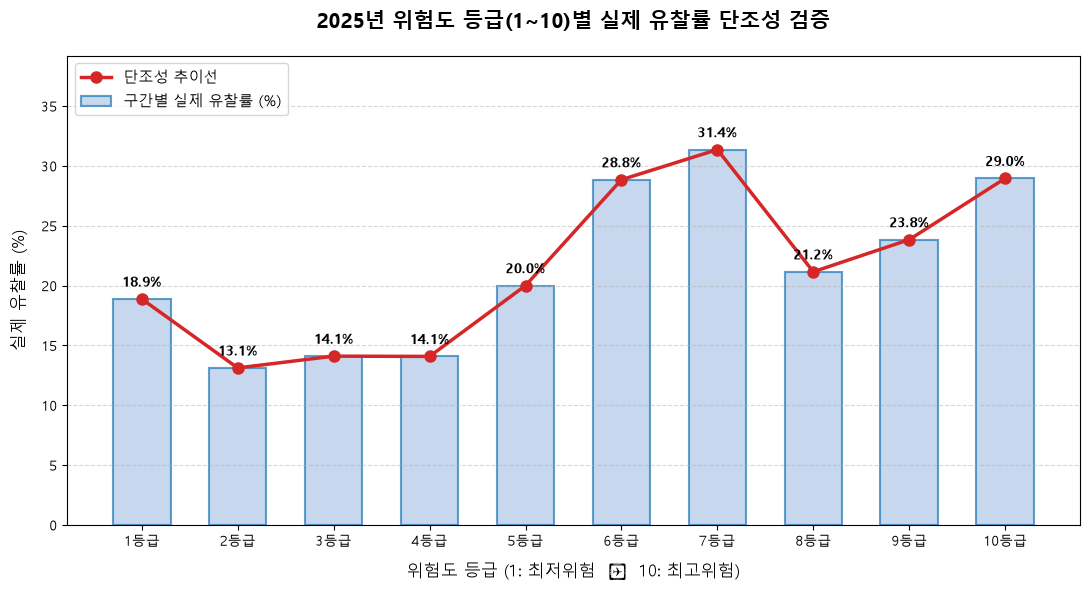

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows 기준 'Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 파일 경로 설정
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
output_result_path = os.path.join(base_path, "evaluation_result_no_suui_2025.csv")

print('📂 저장된 평가 결과 파일 로드 중...')
df_evaluated = pd.read_csv(output_result_path, encoding='utf-8-sig')

# 2. 등급별 집계 테이블 재생성
monotonicity_table = df_evaluated.groupby('risk_decile', observed=False).agg(
    total_count=('fail_yn', 'count'),
    actual_fail_count=('fail_yn', 'sum')
).reset_index()

monotonicity_table['actual_fail_rate'] = monotonicity_table['actual_fail_count'] / monotonicity_table['total_count']
monotonicity_table['risk_decile'] = monotonicity_table['risk_decile'].astype(int)

# 3. 그래프 시각화
plt.figure(figsize=(11, 6))

# 배경 막대그래프
bars = plt.bar(
    monotonicity_table['risk_decile'], 
    monotonicity_table['actual_fail_rate'] * 100, 
    color='#aec7e8', 
    alpha=0.7, 
    edgecolor='#1f77b4',
    linewidth=1.5,
    width=0.6,
    label='구간별 실제 유찰률 (%)'
)

# 트렌드 파악을 위한 꺾은선 그래프
plt.plot(
    monotonicity_table['risk_decile'], 
    monotonicity_table['actual_fail_rate'] * 100, 
    color='#d62728', 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    label='단조성 추이선'
)

# 그래프 디자인 요소 추가
plt.title('2025년 위험도 등급(1~10)별 실제 유찰률 단조성 검증', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('위험도 등급 (1: 최저위험  ➔  10: 최고위험)', fontsize=12, labelpad=10)
plt.ylabel('실제 유찰률 (%)', fontsize=12, labelpad=10)
plt.xticks(range(1, 11), [f'{i}등급' for i in range(1, 11)], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

# 각 막대 위/점 위에 수치(%) 표기
for bar, rate in zip(bars, monotonicity_table['actual_fail_rate']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 0.8, 
        f'{rate*100:.1f}%', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

plt.ylim(0, max(monotonicity_table['actual_fail_rate'] * 100) * 1.25)
plt.tight_layout()

# 그래프 출력
plt.show()

In [5]:
# 0929 3단계 2021~2023 파일을 기준으로 2024 검증 

📂 마스터 파일 로드 중...
   - 전처리 완료된 총 데이터 수: 34,190 건

--------------------------------------------------
[Step 1] 2021~2023년 데이터 기반 정식 룩업 테이블 구축 및 표본 보정 중...
   - 표본 보정 완료된 룩업 테이블 생성 완료 (총 894개 조합)
   - 저장 경로: C:\repository\defense-procurement-risk-dashboard\data-kpi\formal_lookup_table_with_shrinkage.csv

--------------------------------------------------
[Step 2] 2024년 데이터에 보정된 룩업 테이블 매핑 및 예비 검증 수행 중...
👉 [2024년 예비 검증 결과] 상위 20% 고위험군 Recall: 28.86%

--------------------------------------------------
[Step 3] 2025년 Out-of-Time(OOT) 최종 검증 수행 중...
🎯 [표본 보정 룩업 기반 연도별 검증 파이프라인 최종 요약 보고]
• 2021~2023 학습 룩업 조합 패턴 수:   894 개
• 2024년 예비 검증 Recall (기준 확정용): 28.86%
• 2025년 최종 OOT 검증 Recall (KPI 1):   28.45%
• 2025년 최종 OOT 검증 단조성 (KPI 2):    Spearman Rho = 0.8788 (p-value: 0.00081)


C:\Users\user\AppData\Local\Temp\ipykernel_20012\1950355586.py:176: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10132 (\N{HEAVY WIDE-HEADED RIGHTWARDS ARROW}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


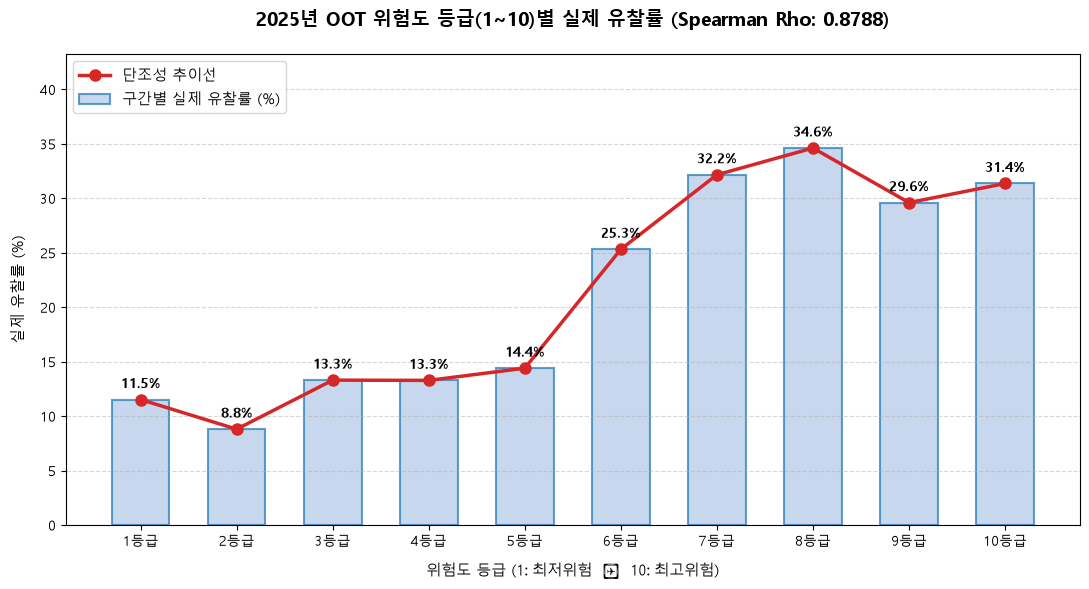

📁 최종 검증 결과 파일 저장 완료: C:\repository\defense-procurement-risk-dashboard\data-kpi\final_evaluation_report_with_shrinkage_2025.csv


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 마스터 파일 로드
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
data_file_path = os.path.join(base_path, "bid_master_2021_2025.csv") 

print('📂 마스터 파일 로드 중...')
df = pd.read_csv(data_file_path, encoding='utf-8-sig')

# 수의계약 제외 전처리
if 'cntrctMth' in df.columns:
    df_filtered = df[~df['cntrctMth'].astype(str).str.contains('수의', na=False)].copy()
else:
    df_filtered = df.copy()

print(f'   - 전처리 완료된 총 데이터 수: {len(df_filtered):,} 건\n')


# ==============================================================================
# [Step 1] 표본 수 보정(Shrinkage)이 적용된 정식 룩업 테이블 생성 (Train: 2021 ~ 2023)
# ==============================================================================
print('--------------------------------------------------')
print('[Step 1] 2021~2023년 데이터 기반 정식 룩업 테이블 구축 및 표본 보정 중...')
df_train = df_filtered[(df_filtered['year'] >= 2021) & (df_filtered['year'] <= 2023)]

group_keys = ['ornt', 'cntrctMth', 'busiDivs'] 

# 1) 조합별 기본 집계
lookup_table = df_train.groupby(group_keys, observed=False).agg(
    train_total_count=('fail_yn', 'count'),
    train_fail_count=('fail_yn', 'sum')
).reset_index()

# 학습 데이터 전체의 평균 유찰률 (Global Prior)
global_mean_fail_prob = df_train['fail_yn'].mean()

# 2) 베이지안 축소(Bayesian Shrinkage) 적용
# 표본 수(train_total_count)가 적은 조합은 극단적인 확률(0% 또는 100%)로 튀지 않도록 
# 전체 평균(global_mean_fail_prob) 쪽으로 부드럽게 끌어당겨 줍니다. (C 조절 계수: 보통 5~10)
C = 5.0 
lookup_table['lookup_fail_prob'] = (
    lookup_table['train_fail_count'] + C * global_mean_fail_prob
) / (
    lookup_table['train_total_count'] + C
)

# 정식 룩업 테이블 파일 저장
lookup_output_path = os.path.join(base_path, "formal_lookup_table_with_shrinkage.csv")
lookup_table.to_csv(lookup_output_path, index=False, encoding='utf-8-sig')
print(f'   - 표본 보정 완료된 룩업 테이블 생성 완료 (총 {len(lookup_table):,}개 조합)')
print(f'   - 저장 경로: {lookup_output_path}\n')


# ==============================================================================
# [Step 2] 2024년 데이터 대상 예비 검증 (목표치 도출용)
# ==============================================================================
print('--------------------------------------------------')
print('[Step 2] 2024년 데이터에 보정된 룩업 테이블 매핑 및 예비 검증 수행 중...')
df_val = df_filtered[df_filtered['year'] == 2024].copy()

df_val = pd.merge(df_val, lookup_table[group_keys + ['lookup_fail_prob']], on=group_keys, how='left')
# 학습 때 없던 신규 조합은 전체 평균으로 대체
df_val['lookup_fail_prob'] = df_val['lookup_fail_prob'].fillna(global_mean_fail_prob)

# 2024년 KPI 1 (Recall) 예비 계산 (상위 20% 고위험군 기준)
threshold_2024 = df_val['lookup_fail_prob'].quantile(0.8)
df_val['is_high_risk'] = df_val['lookup_fail_prob'] >= threshold_2024

total_fails_2024 = df_val['fail_yn'].sum()
captured_fails_2024 = df_val[(df_val['is_high_risk']) & (df_val['fail_yn'] == 1)].shape[0]
val_recall = (captured_fails_2024 / total_fails_2024) * 100 if total_fails_2024 > 0 else 0

print(f'👉 [2024년 예비 검증 결과] 상위 20% 고위험군 Recall: {val_recall:.2f}%\n')


# ==============================================================================
# [Step 3] 2025년 데이터 대상 최종 OOT 검증
# ==============================================================================
print('--------------------------------------------------')
print('[Step 3] 2025년 Out-of-Time(OOT) 최종 검증 수행 중...')
df_test = df_filtered[df_filtered['year'] == 2025].copy()

df_test = pd.merge(df_test, lookup_table[group_keys + ['lookup_fail_prob']], on=group_keys, how='left')
df_test['lookup_fail_prob'] = df_test['lookup_fail_prob'].fillna(global_mean_fail_prob)

# 1) KPI 1 (Recall) 최종 계산
threshold_2025 = df_test['lookup_fail_prob'].quantile(0.8)
df_test['is_high_risk'] = df_test['lookup_fail_prob'] >= threshold_2025

total_fails_2025 = df_test['fail_yn'].sum()
captured_fails_2025 = df_test[(df_test['is_high_risk']) & (df_test['fail_yn'] == 1)].shape[0]
test_recall = (captured_fails_2025 / total_fails_2025) * 100 if total_fails_2025 > 0 else 0

# 2) KPI 2 (Monotonicity / Spearman's Rho) 최종 계산
df_test['risk_decile'] = pd.qcut(
    df_test['lookup_fail_prob'].rank(method='first'), 
    10, 
    labels=range(1, 11)
)

decile_summary = df_test.groupby('risk_decile', observed=False).agg(
    total_count=('fail_yn', 'count'),
    actual_fail_count=('fail_yn', 'sum')
).reset_index()

decile_summary['actual_fail_rate'] = decile_summary['actual_fail_count'] / decile_summary['total_count']
decile_summary['risk_decile'] = decile_summary['risk_decile'].astype(int)

rho, p_value = spearmanr(decile_summary['risk_decile'], decile_summary['actual_fail_rate'])

print('='*50)
print('🎯 [표본 보정 룩업 기반 연도별 검증 파이프라인 최종 요약 보고]')
print('='*50)
print(f'• 2021~2023 학습 룩업 조합 패턴 수:   {len(lookup_table):,} 개')
print(f'• 2024년 예비 검증 Recall (기준 확정용): {val_recall:.2f}%')
print(f'• 2025년 최종 OOT 검증 Recall (KPI 1):   {test_recall:.2f}%')
print(f'• 2025년 최종 OOT 검증 단조성 (KPI 2):    Spearman Rho = {rho:.4f} (p-value: {p_value:.5f})')
print('='*50)

# ==============================================================================
# [Step 4] 2025년 KPI 2 단조성 시각화 그래프 출력
# ==============================================================================
plt.figure(figsize=(11, 6))

bars = plt.bar(
    decile_summary['risk_decile'], 
    decile_summary['actual_fail_rate'] * 100, 
    color='#aec7e8', 
    alpha=0.7, 
    edgecolor='#1f77b4',
    linewidth=1.5,
    width=0.6,
    label='구간별 실제 유찰률 (%)'
)

plt.plot(
    decile_summary['risk_decile'], 
    decile_summary['actual_fail_rate'] * 100, 
    color='#d62728', 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    label='단조성 추이선'
)

plt.title(f'2025년 OOT 위험도 등급(1~10)별 실제 유찰률 (Spearman Rho: {rho:.4f})', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('위험도 등급 (1: 최저위험  ➔  10: 최고위험)', fontsize=11, labelpad=10)
plt.ylabel('실제 유찰률 (%)', fontsize=11, labelpad=10)
plt.xticks(range(1, 11), [f'{i}등급' for i in range(1, 11)], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

for bar, rate in zip(bars, decile_summary['actual_fail_rate']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 0.8, 
        f'{rate*100:.1f}%', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

plt.ylim(0, max(decile_summary['actual_fail_rate'] * 100) * 1.25)
plt.tight_layout()
plt.show()

# 최종 결과 파일 저장
output_path = os.path.join(base_path, "final_evaluation_report_with_shrinkage_2025.csv")
df_test.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'📁 최종 검증 결과 파일 저장 완료: {output_path}')

In [7]:
import os
import pandas as pd

base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
data_file_path = os.path.join(base_path, "bid_master_2021_2025.csv") 

df = pd.read_csv(data_file_path, encoding='utf-8-sig', nrows=5)
print("📋 마스터 파일 컬럼 목록:")
print(list(df.columns))

📋 마스터 파일 컬럼 목록:
['bidMth', 'bidNm', 'bidResult', 'cntrctMth', 'dcsNo', 'demandYear', 'iemNo', 'opengDate', 'opengDt', 'ornt', 'orntCode', 'pblancNo', 'pblancOdr', 'pblancSe', 'sucbidrDecsnMth', 'busiDivs', 'fail_yn', 'year']


In [12]:
import os
import pandas as pd

# 1. 파일 경로 설정
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
master_file_path = os.path.join(base_path, 'bid_master_2021_2025.csv')
output_path = os.path.join(base_path, 'bid_master_2021_2023.csv')

print('📂 기존 통합 마스터 파일 로드 중...')
df_master = pd.read_csv(master_file_path, encoding='utf-8-sig')

print(f'   - 전체 통합 마스터 데이터 총 건수: {len(df_master):,}건')

# 2. 2021~2023년 데이터만 필터링
df_master_2021_2023 = df_master[
    (df_master['year'] >= 2021) & (df_master['year'] <= 2023)
].copy()

print(
    f'   - 2021~2023년 필터링된 데이터 건수:'
    f' {len(df_master_2021_2023):,}건'
)

# 3. 2021~2023년 전용 마스터 파일 저장
df_master_2021_2023.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f'🚀 2021~2023년 마스터 파일 저장 완료!\n📁 저장 경로: {output_path}')

📂 기존 통합 마스터 파일 로드 중...
   - 전체 통합 마스터 데이터 총 건수: 38,114건
   - 2021~2023년 필터링된 데이터 건수: 24,497건
🚀 2021~2023년 마스터 파일 저장 완료!
📁 저장 경로: C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\bid_master_2021_2023.csv


In [13]:
## 2021~2023 룩업테이블 

In [14]:
import os
import pandas as pd

# 1. 경로 설정 (OneDrive 카카오톡 받은 파일\bid 경로 적용)
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
master_path = os.path.join(base_path, 'bid_master_2021_2025.csv')
output_path = os.path.join(
    base_path, 'risk_lookup_table_absorbed_2021_2023.csv'
)

print('📂 통합 마스터 파일 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')


# 2. 발주기관 그룹 매핑 함수 (공군 계열 명확히 분리)
def map_org_group(val):
  val_str = str(val)
  if (
      '육군' in val_str
      or '3군단' in val_str
      or '군단' in val_str
      or '사령부' in val_str
  ):
    return '1. 육군계열'
  elif '공군' in val_str:
    return '2. 공군계열'
  elif '해군' in val_str or '해병대' in val_str:
    return '3. 해군/해병대계열'
  elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
    return '4. 국방부직할/합동'
  else:
    return '기타계열'


df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# 3. 학습 기간 설정: 2021년 ~ 2023년 데이터만 필터링 (수정 완료!)
print('🔍 2021~2023년 과거 학습 데이터 추출 및 조합 집계 중...')
df_train = df_master[
    (df_master['year'] >= 2021) & (df_master['year'] <= 2023)
].copy()

# 4. 3가지 기준(org_group, mthd_group, busiDivs)으로 초기 룩업 테이블 생성
df = (
    df_train.groupby(['org_group', 'mthd_group', 'busiDivs'])
    .agg(sample_count=('fail_yn', 'count'), fail_rate=('fail_yn', 'mean'))
    .reset_index()
)

# 정밀 가중평균 계산을 위한 유찰 건수 복원
df['fail_count'] = df['sample_count'] * df['fail_rate']

# 5. 데이터 분리: 10개 이상(기준 테이블) vs 10개 미만(합산 대상 소표본)
large_df = df[df['sample_count'] >= 10].copy().reset_index(drop=True)
small_df = df[df['sample_count'] < 10].copy().reset_index(drop=True)

print(f'✨ 기준 유지 데이터 (10건 이상): {len(large_df):,}개 행')
print(f'➕ 흡수시킬 소표본 데이터 (10건 미만): {len(small_df):,}개 행\n')

# 6. 소표본 행들을 우선순위에 따라 10개 이상 행들에 흡수시키기
print('🔄 소표본 데이터 상위 그룹 흡수(Absorption) 작업 중...')
for idx, row in small_df.iterrows():
  org = row['org_group']
  mthd = row['mthd_group']
  busi = row['busiDivs']
  s_cnt = row['sample_count']
  f_cnt = row['fail_count']

  matched = False

  # [1순위] 기관 + 계약방식이 일치하는 10개 이상 행 찾기
  cand1 = large_df[
      (large_df['org_group'] == org) & (large_df['mthd_group'] == mthd)
  ]
  if not cand1.empty:
    target_idx = cand1['sample_count'].idxmax()
    large_df.loc[target_idx, 'sample_count'] += s_cnt
    large_df.loc[target_idx, 'fail_count'] += f_cnt
    matched = True
  else:
    # [2순위] 기관 + 사업유형이 일치하는 10개 이상 행 찾기
    cand2 = large_df[
        (large_df['org_group'] == org) & (large_df['busiDivs'] == busi)
    ]
    if not cand2.empty:
      target_idx = cand2['sample_count'].idxmax()
      large_df.loc[target_idx, 'sample_count'] += s_cnt
      large_df.loc[target_idx, 'fail_count'] += f_cnt
      matched = True

  # [안전장치] 만약 1, 2순위 모두 못 찾았다면 해당 기관의 가장 큰 그룹에 흡수
  if not matched:
    cand3 = large_df[large_df['org_group'] == org]
    if not cand3.empty:
      target_idx = cand3['sample_count'].idxmax()
      large_df.loc[target_idx, 'sample_count'] += s_cnt
      large_df.loc[target_idx, 'fail_count'] += f_cnt

# 7. 흡수 완료 후 유찰률(fail_rate) 재계산 및 포맷팅
large_df['fail_rate'] = large_df['fail_count'] / large_df['sample_count']
large_df['fail_rate_pct'] = (
    (large_df['fail_rate'] * 100).round(2).astype(str) + '%'
)

# 8. 최종 결과 저장
large_df[[
    'org_group',
    'mthd_group',
    'busiDivs',
    'sample_count',
    'fail_rate',
    'fail_rate_pct',
]].to_csv(output_path, index=False, encoding='utf-8-sig')

print(
    '🚀 2021~2023년 기준 공군 포함 및 소표본 흡수 완료된 최종 룩업 테이블 저장'
    ' 완료!'
)
print(f'📁 저장 경로: {output_path}')

# 기관별 분포 확인용 샘플 출력
print('\n📊 [생성된 룩업 테이블 내 기관별 분포 요약]')
print(large_df['org_group'].value_counts())

📂 통합 마스터 파일 로드 중...
🔍 2021~2023년 과거 학습 데이터 추출 및 조합 집계 중...
✨ 기준 유지 데이터 (10건 이상): 43개 행
➕ 흡수시킬 소표본 데이터 (10건 미만): 19개 행

🔄 소표본 데이터 상위 그룹 흡수(Absorption) 작업 중...
🚀 2021~2023년 기준 공군 포함 및 소표본 흡수 완료된 최종 룩업 테이블 저장 완료!
📁 저장 경로: C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\risk_lookup_table_absorbed_2021_2023.csv

📊 [생성된 룩업 테이블 내 기관별 분포 요약]
org_group
기타계열           13
1. 육군계열        10
2. 공군계열         9
4. 국방부직할/합동     6
3. 해군/해병대계열     5
Name: count, dtype: int64


In [15]:
## 2021~2023 카이제곱

In [16]:
import os
import pandas as pd
from scipy.stats import chi2_contingency

# 1. 경로 설정 (OneDrive 카카오톡 받은 파일\bid 경로 및 2021~2023년 파일명 반영)
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
file_path = os.path.join(
    base_path, 'risk_lookup_table_absorbed_2021_2023.csv'
)

print('📂 2021~2023년 흡수 룩업 테이블 파일 로드 중...')
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 카이제곱 검정을 위한 실패(유찰) 건수 및 성공 건수 복원
df['fail_count'] = (df['sample_count'] * df['fail_rate']).round()
df['success_count'] = df['sample_count'] - df['fail_count']

print('=' * 65)
print('🔍 [카이제곱 검정 과정 상세 출력]')
print('=' * 65)

# 검정 대상 변수 목록
target_vars = ['org_group', 'mthd_group', 'busiDivs']

for col in target_vars:
  if col in df.columns:
    print(
        '\n-------------------------------------------------------------'
    )
    print(f'📌 검정 변수: [{col}]')
    print(
        '-------------------------------------------------------------'
    )

    # [과정 1] 변수별 유찰(Fail) 및 성공(Success) 교차표(Contingency Table) 생성
    contingency = df.groupby(col)[['fail_count', 'success_count']].sum()
    print('1단계: 교차표 (Contingency Table - 관측빈도)')
    print(contingency)
    print('\n')

    # [과정 2] scipy 라이브러리를 통한 카이제곱 통계량, 자유도, 기대빈도 계산
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # 기대빈도 테이블 확인 (카이제곱 조건 검증용)
    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=['expected_fail', 'expected_success'],
    )
    print('2단계: 기대빈도 (Expected Frequency)')
    print(expected_df.round(2))
    print('\n')

    # [과정 3] 최종 통계 결과 및 판정
    print(f'3단계: 검정 결과 수치')
    print(f'  - 카이제곱 통계량 (Chi2) : {chi2:.4f}')
    print(f'  - 자유도 (Degree of Freedom, dof) : {dof}')
    print(f'  - p-value (유의확률) : {p_value:.5e}')

    if p_value < 0.05:
      print('  👉 [판정] p-value < 0.05 이므로 귀무가설 기각!')
      print(
          f'         -> [{col}] 변수는 유찰과 통계적으로 **유의한 연관**이'
          ' 있습니다. 모델에 유지합니다.'
      )
    else:
      print('  👉 [판정] p-value >= 0.05 이므로 귀무가설 채택')
      print(
          f'         -> [{col}] 변수는 유찰과 연관성이 낮습니다. 위험도 계산에서'
          ' 제외를 검토합니다.'
      )

print('\n' + '=' * 65)
print('✨ 모든 변수에 대한 카이제곱 검정 과정이 완료되었습니다.')
print('=' * 65)

📂 2021~2023년 흡수 룩업 테이블 파일 로드 중...
🔍 [카이제곱 검정 과정 상세 출력]

-------------------------------------------------------------
📌 검정 변수: [org_group]
-------------------------------------------------------------
1단계: 교차표 (Contingency Table - 관측빈도)
             fail_count  success_count
org_group                             
1. 육군계열          3661.0         9066.0
2. 공군계열           214.0          424.0
3. 해군/해병대계열        52.0          362.0
4. 국방부직할/합동       122.0          243.0
기타계열             2493.0         7860.0


2단계: 기대빈도 (Expected Frequency)
             expected_fail  expected_success
org_group                                   
1. 육군계열            3398.78           9328.22
2. 공군계열             170.38            467.62
3. 해군/해병대계열         110.56            303.44
4. 국방부직할/합동          97.47            267.53
기타계열               2764.80           7588.20


3단계: 검정 결과 수치
  - 카이제곱 통계량 (Chi2) : 130.0307
  - 자유도 (Degree of Freedom, dof) : 4
  - p-value (유의확률) : 3.83569e-27
  👉 [판정] p-value < 0.05 이

In [1]:
import os
import pandas as pd

# 1. 파일 경로 설정 (OneDrive 카카오톡 받은 파일\bid 경로 및 2021~2023 룩업, 2024년 결과 경로 반영)
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
master_path = os.path.join(base_path, 'bid_master_2021_2025.csv')
lookup_path = os.path.join(
    base_path, 'risk_lookup_table_absorbed_2021_2023.csv'
)
output_result_path = os.path.join(
    base_path, 'evaluation_result_2024.csv'
)

print('📂 마스터 파일 및 2021~2023 흡수 룩업 테이블 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')
df_lookup = pd.read_csv(lookup_path, encoding='utf-8-sig')


# 2. 발주기관 그룹 매핑 함수 (공군 포함)
def map_org_group(val):
  val_str = str(val)
  if (
      '육군' in val_str
      or '3군단' in val_str
      or '군단' in val_str
      or '사령부' in val_str
  ):
    return '1. 육군계열'
  elif '공군' in val_str:
    return '2. 공군계열'
  elif '해군' in val_str or '해병대' in val_str:
    return '3. 해군/해병대계열'
  elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
    return '4. 국방부직할/합동'
  else:
    return '기타계열'


df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# 3. 2024년 테스트 데이터 추출 (수정 완료!)
df_2024 = df_master[df_master['year'] == 2024].copy()
print(f'✨ 2024년 검증 대상 총 공고 수: {len(df_2024):,}건')

# 4. 흡수 완료된 룩업 테이블과 2024년 데이터 병합 (Left Join)
print('🔗 2024년 공고 데이터에 리스크 룩업 테이블 매핑 중...')
df_evaluated = pd.merge(
    df_2024,
    df_lookup[['org_group', 'mthd_group', 'busiDivs', 'fail_rate']],
    on=['org_group', 'mthd_group', 'busiDivs'],
    how='left',
)

# 매핑되지 않은 누락 데이터는 룩업 테이블 전체 평균 유찰률로 대체
global_mean_fail_rate = df_lookup['fail_rate'].mean()
df_evaluated['fail_rate'] = df_evaluated['fail_rate'].fillna(
    global_mean_fail_rate
)

# 5. KPI (사전식별률 / Recall) 산출
# 예측된 유찰률이 상위 20% 이내인 공고를 고위험군으로 지정
risk_threshold = df_evaluated['fail_rate'].quantile(0.80)
df_evaluated['is_predicted_high_risk'] = (
    df_evaluated['fail_rate'] >= risk_threshold
)

total_actual_fails = df_evaluated['fail_yn'].sum()
detected_fails = df_evaluated[
    (df_evaluated['fail_yn'] == 1)
    & (df_evaluated['is_predicted_high_risk'] == True)
].shape[0]

# 사전식별률(Recall) = (고위험군으로 예측한 실제 유찰 건수) / (2024년 실제 총 유찰 건수)
kpi_recall = (
    detected_fails / total_actual_fails if total_actual_fails > 0 else 0
)

print('\n' + '=' * 50)
print('🎯 [2024년 모델 최종 성과 지표 (KPI 채점)]')
print('=' * 50)
print(f'  - 2024년 총 공고 건수 : {len(df_evaluated):,}건')
print(f'  - 2024년 실제 총 유찰 건수 : {total_actual_fails:,}건')
print(f'  - 모델이 고위험군으로 사전에 포착한 실제 유찰 건수 : {detected_fails:,}건')
print(f'  - 🏆 사전식별률 (KPI / Recall) : {kpi_recall * 100:.2f}%')
print('=' * 50)

# 6. 상세 채점 결과 저장
df_evaluated.to_csv(output_result_path, index=False, encoding='utf-8-sig')
print(f'\n📁 2024년 상세 채점 결과 저장 완료:\n{output_result_path}')

📂 마스터 파일 및 2021~2023 흡수 룩업 테이블 로드 중...
✨ 2024년 검증 대상 총 공고 수: 7,119건
🔗 2024년 공고 데이터에 리스크 룩업 테이블 매핑 중...

🎯 [2024년 모델 최종 성과 지표 (KPI 채점)]
  - 2024년 총 공고 건수 : 7,119건
  - 2024년 실제 총 유찰 건수 : 1,794건
  - 모델이 고위험군으로 사전에 포착한 실제 유찰 건수 : 1,167건
  - 🏆 사전식별률 (KPI / Recall) : 65.05%

📁 2024년 상세 채점 결과 저장 완료:
C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\evaluation_result_2024.csv


In [2]:
import os
import pandas as pd

# 1. 경로 설정 (OneDrive 카카오톡 받은 파일\bid 경로)
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
master_path = os.path.join(base_path, 'bid_master_2021_2025.csv')
lookup_output_path = os.path.join(
    base_path, 'risk_lookup_table_absorbed_2021_2023_no_수의계약.csv'
)
evaluation_output_path = os.path.join(
    base_path, 'evaluation_result_2024_no_수의계약.csv'
)

print('📂 통합 마스터 파일 로드 중...')
df_master = pd.read_csv(master_path, encoding='utf-8-sig')

# ==========================================
# [중요] 수의계약 데이터 원천 제외
# ==========================================
initial_count = len(df_master)
df_master = df_master[df_master['cntrctMth'] != '수의계약'].copy()
excluded_count = initial_count - len(df_master)
print(
    f'🚫 수의계약 데이터 {excluded_count:,}건 제외 완료 (남은 데이터:'
    f' {len(df_master):,}건)\n'
)


# 2. 발주기관 그룹 매핑 함수 (공군 계열 명확히 분리)
def map_org_group(val):
  val_str = str(val)
  if (
      '육군' in val_str
      or '3군단' in val_str
      or '군단' in val_str
      or '사령부' in val_str
  ):
    return '1. 육군계열'
  elif '공군' in val_str:
    return '2. 공군계열'
  elif '해군' in val_str or '해병대' in val_str:
    return '3. 해군/해병대계열'
  elif '국방부' in val_str or '합동' in val_str or '근무지원단' in val_str:
    return '4. 국방부직할/합동'
  else:
    return '기타계열'


df_master['org_group'] = df_master['ornt'].apply(map_org_group)
df_master['mthd_group'] = df_master['cntrctMth']

# ==========================================
# PART 1. 2021~2023년 룩업 테이블 생성 (수의계약 제외)
# ==========================================
print('🔍 [Step 1] 2021~2023년 학습 데이터 추출 및 소표본 흡수 룩업 생성 중...')
df_train = df_master[
    (df_master['year'] >= 2021) & (df_master['year'] <= 2023)
].copy()

df_lookup_base = (
    df_train.groupby(['org_group', 'mthd_group', 'busiDivs'])
    .agg(sample_count=('fail_yn', 'count'), fail_rate=('fail_yn', 'mean'))
    .reset_index()
)
df_lookup_base['fail_count'] = (
    df_lookup_base['sample_count'] * df_lookup_base['fail_rate']
)

large_df = df_lookup_base[df_lookup_base['sample_count'] >= 10].copy().reset_index(drop=True)
small_df = df_lookup_base[df_lookup_base['sample_count'] < 10].copy().reset_index(drop=True)

for idx, row in small_df.iterrows():
  org = row['org_group']
  mthd = row['mthd_group']
  busi = row['busiDivs']
  s_cnt = row['sample_count']
  f_cnt = row['fail_count']

  matched = False
  cand1 = large_df[
      (large_df['org_group'] == org) & (large_df['mthd_group'] == mthd)
  ]
  if not cand1.empty:
    target_idx = cand1['sample_count'].idxmax()
    large_df.loc[target_idx, 'sample_count'] += s_cnt
    large_df.loc[target_idx, 'fail_count'] += f_cnt
    matched = True
  else:
    cand2 = large_df[
        (large_df['org_group'] == org) & (large_df['busiDivs'] == busi)
    ]
    if not cand2.empty:
      target_idx = cand2['sample_count'].idxmax()
      large_df.loc[target_idx, 'sample_count'] += s_cnt
      large_df.loc[target_idx, 'fail_count'] += f_cnt
      matched = True

  if not matched:
    cand3 = large_df[large_df['org_group'] == org]
    if not cand3.empty:
      target_idx = cand3['sample_count'].idxmax()
      large_df.loc[target_idx, 'sample_count'] += s_cnt
      large_df.loc[target_idx, 'fail_count'] += f_cnt

large_df['fail_rate'] = large_df['fail_count'] / large_df['sample_count']
large_df['fail_rate_pct'] = (
    (large_df['fail_rate'] * 100).round(2).astype(str) + '%'
)

df_lookup = large_df[
    [
        'org_group',
        'mthd_group',
        'busiDivs',
        'sample_count',
        'fail_rate',
        'fail_rate_pct',
    ]
].copy()
df_lookup.to_csv(lookup_output_path, index=False, encoding='utf-8-sig')
print(f'✨ 수의계약 제외 룩업 테이블 저장 완료: {lookup_output_path}\n')


# ==========================================
# PART 2. 2024년 테스트 데이터 평가 (수의계약 제외)
# ==========================================
print('🎯 [Step 2] 2024년 공고 데이터 성과 평가(KPI 채점) 진행 중...')
df_2024 = df_master[df_master['year'] == 2024].copy()
print(f'✨ 2024년 검증 대상 총 공고 수 (수의계약 제외): {len(df_2024):,}건')

df_evaluated = pd.merge(
    df_2024,
    df_lookup[['org_group', 'mthd_group', 'busiDivs', 'fail_rate']],
    on=['org_group', 'mthd_group', 'busiDivs'],
    how='left',
)

global_mean_fail_rate = df_lookup['fail_rate'].mean()
df_evaluated['fail_rate'] = df_evaluated['fail_rate'].fillna(
    global_mean_fail_rate
)

risk_threshold = df_evaluated['fail_rate'].quantile(0.80)
df_evaluated['is_predicted_high_risk'] = (
    df_evaluated['fail_rate'] >= risk_threshold
)

total_actual_fails = df_evaluated['fail_yn'].sum()
detected_fails = df_evaluated[
    (df_evaluated['fail_yn'] == 1)
    & (df_evaluated['is_predicted_high_risk'] == True)
].shape[0]

kpi_recall = (
    detected_fails / total_actual_fails if total_actual_fails > 0 else 0
)

print('\n' + '=' * 50)
print('🎯 [수의계약 제외 - 2024년 모델 최종 성과 지표 (KPI 채점)]')
print('=' * 50)
print(f'  - 2024년 총 공고 건수 : {len(df_evaluated):,}건')
print(f'  - 2024년 실제 총 유찰 건수 : {total_actual_fails:,}건')
print(f'  - 모델이 고위험군으로 사전에 포착한 실제 유찰 건수 : {detected_fails:,}건')
print(f'  - 🏆 사전식별률 (KPI / Recall) : {kpi_recall * 100:.2f}%')
print('=' * 50)

df_evaluated.to_csv(evaluation_output_path, index=False, encoding='utf-8-sig')
print(f'\n📁 2024년 상세 채점 결과 저장 완료:\n{evaluation_output_path}')

📂 통합 마스터 파일 로드 중...
🚫 수의계약 데이터 3,924건 제외 완료 (남은 데이터: 34,190건)

🔍 [Step 1] 2021~2023년 학습 데이터 추출 및 소표본 흡수 룩업 생성 중...
✨ 수의계약 제외 룩업 테이블 저장 완료: C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\risk_lookup_table_absorbed_2021_2023_no_수의계약.csv

🎯 [Step 2] 2024년 공고 데이터 성과 평가(KPI 채점) 진행 중...
✨ 2024년 검증 대상 총 공고 수 (수의계약 제외): 6,813건

🎯 [수의계약 제외 - 2024년 모델 최종 성과 지표 (KPI 채점)]
  - 2024년 총 공고 건수 : 6,813건
  - 2024년 실제 총 유찰 건수 : 1,521건
  - 모델이 고위험군으로 사전에 포착한 실제 유찰 건수 : 882건
  - 🏆 사전식별률 (KPI / Recall) : 57.99%

📁 2024년 상세 채점 결과 저장 완료:
C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\evaluation_result_2024_no_수의계약.csv


In [1]:
## kpi2 2021~2023

In [7]:
import os
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 1. 파일 경로 설정 (수의계약이 제외된 2024년 평가 결과 파일 로드)
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
result_path = os.path.join(base_path, 'evaluation_result_2024_no_수의계약.csv')

print('📂 수의계약 제외 2024년 평가 결과 파일 로드 중...')
df = pd.read_csv(result_path, encoding='utf-8-sig')

# 2. 예측 위험도(fail_rate) 기준 오름차순 정렬 후 인덱스를 정확히 10등분(1~10등급)으로 분할
df = df.sort_values(by='fail_rate', ascending=True).reset_index(drop=True)

# DataFrame의 index 자체를 10개로 분할
indices_chunks = np.array_split(df.index, 10)
for i, idx in enumerate(indices_chunks):
  df.loc[idx, 'risk_decile'] = i + 1

df['risk_decile'] = df['risk_decile'].astype(int)

# 3. 등급별 실제 유찰률 및 통계 집계
kpi2_summary = (
    df.groupby('risk_decile')
    .agg(
        total_count=('fail_yn', 'count'),  # 구간별 총 공고 수
        actual_fail_count=('fail_yn', 'sum'),  # 구간별 실제 유찰 건수
        actual_fail_rate=('fail_yn', 'mean'),  # 구간별 실제 유찰률 (평균)
        mean_predicted_rate=('fail_rate', 'mean'),  # 구간별 평균 예측 위험도
    )
    .reset_index()
)

# 퍼센트 포맷팅 추가
kpi2_summary['actual_fail_rate_pct'] = (
    kpi2_summary['actual_fail_rate'] * 100
).round(2).astype(str) + '%'
kpi2_summary['mean_predicted_rate_pct'] = (
    kpi2_summary['mean_predicted_rate'] * 100
).round(2).astype(str) + '%'

print('\n' + '=' * 75)
print('📊 [KPI 2: 단조성 구간 위험도 - 정확히 10등급별 실제 유찰률 요약]')
print('=' * 75)
print(
    kpi2_summary[[
        'risk_decile',
        'total_count',
        'actual_fail_count',
        'mean_predicted_rate_pct',
        'actual_fail_rate_pct',
    ]].to_string(index=False)
)
print('=' * 75)

# 4. 스피어만 순위 상관계수(Spearman's Rho) 산출
rho, p_value = spearmanr(
    kpi2_summary['risk_decile'], kpi2_summary['actual_fail_rate']
)

print('\n' + '=' * 75)
print('🎯 [수의계약 제외 - 2024년 모델 KPI 2 최종 성과 지표 (10등급)]')
print('=' * 75)
print(f"  - 스피어만 순위 상관계수 (Spearman's Rho) : {rho:.4f}")
print(f'  - p-value (유의확률) : {p_value:.5e}')
print(f'  - 목표 수준 (Target) : >= 0.70')

if rho >= 0.7:
  print('  👉 [판정] 🏆 목표 수준(0.7 이상) 달성! 위험도 순위 변별력이 매우 우수합니다.')
else:
  print(
      '  👉 [판정] ⚠️ 순위 상관계수가 0.7 미만입니다. 등급별 우상향 추이를'
      ' 재검토하세요.'
  )
print('=' * 75)

# 5. 요약 결과 저장
kpi2_output_path = os.path.join(
    base_path, 'kpi2_summary_2024_no_수의계약_10decile.csv'
)
kpi2_summary.to_csv(kpi2_output_path, index=False, encoding='utf-8-sig')
print(f'\n📁 KPI 2 10등급 요약 결과 저장 완료:\n{kpi2_output_path}')

📂 수의계약 제외 2024년 평가 결과 파일 로드 중...

📊 [KPI 2: 단조성 구간 위험도 - 정확히 10등급별 실제 유찰률 요약]
 risk_decile  total_count  actual_fail_count mean_predicted_rate_pct actual_fail_rate_pct
           1          682                116                   9.88%               17.01%
           2          682                 88                  12.37%                12.9%
           3          682                 98                  13.16%               14.37%
           4          681                 98                   13.8%               14.39%
           5          681                191                  16.19%               28.05%
           6          681                191                  18.48%               28.05%
           7          681                204                   18.8%               29.96%
           8          681                167                   18.8%               24.52%
           9          681                146                  18.87%               21.44%
          10          

📊 KPI 2 시각화 차트 저장 완료:
C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid\kpi2_monotonicity_chart.png


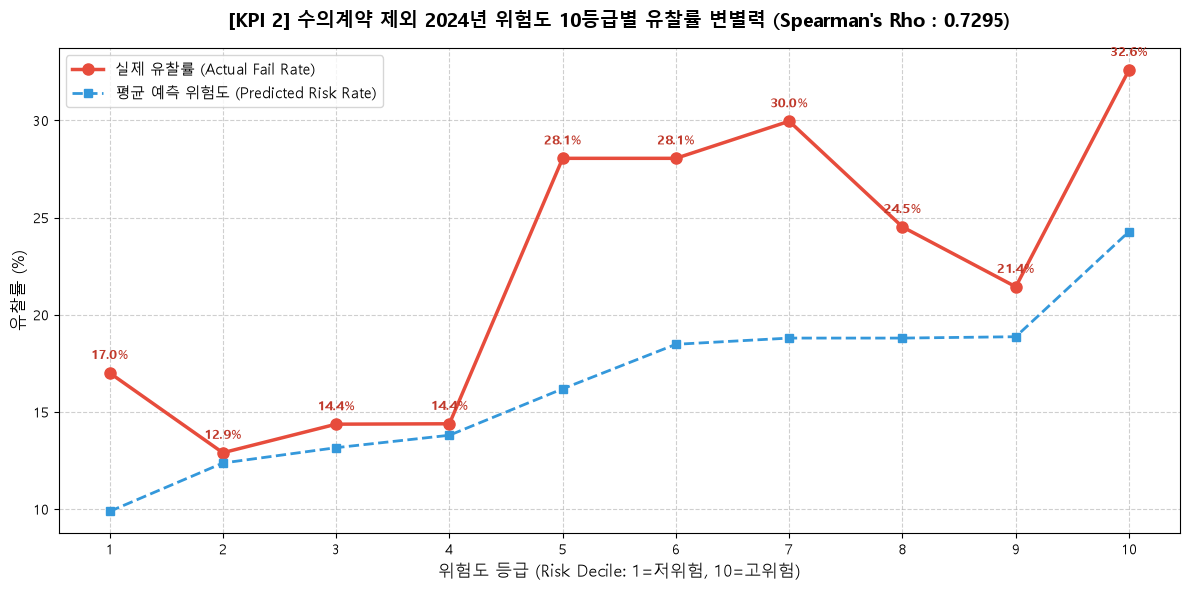

In [8]:
## 단조성 검증 시각화
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 한글 폰트 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

# 1. KPI 2 요약 파일 로드
base_path = r'C:\Users\user\OneDrive\Documents\카카오톡 받은 파일\bid'
summary_path = os.path.join(base_path, 'kpi2_summary_2024_no_수의계약_10decile.csv')

df_kpi2 = pd.read_csv(summary_path, encoding='utf-8-sig')

# 퍼센트 데이터를 실수형(float)으로 변환 (그래프 그리기용)
df_kpi2['actual_fail_rate_val'] = (
    df_kpi2['actual_fail_rate_pct'].str.rstrip('%').astype(float)
)
df_kpi2['mean_predicted_rate_val'] = (
    df_kpi2['mean_predicted_rate_pct'].str.rstrip('%').astype(float)
)

# 2. 시각화 그래프 설정
plt.figure(figsize=(12, 6))

# 실제 유찰률 선 그래프 (Main Trend)
plt.plot(
    df_kpi2['risk_decile'],
    df_kpi2['actual_fail_rate_val'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#e74c3c',
    label='실제 유찰률 (Actual Fail Rate)',
)

# 평균 예측 위험도 선 그래프 (Comparison)
plt.plot(
    df_kpi2['risk_decile'],
    df_kpi2['mean_predicted_rate_val'],
    marker='s',
    linewidth=2,
    linestyle='--',
    markersize=6,
    color='#3498db',
    label='평균 예측 위험도 (Predicted Risk Rate)',
)

# 3. 그래프 디자인 및 레이블 조정
plt.title(
    '[KPI 2] 수의계약 제외 2024년 위험도 10등급별 유찰률 변별력 (Spearman\'s Rho'
    ' : 0.7295)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('위험도 등급 (Risk Decile: 1=저위험, 10=고위험)', fontsize=12)
plt.ylabel('유찰률 (%)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# 데이터 포인트마다 실제 값 텍스트 표시
for i, row in df_kpi2.iterrows():
  plt.annotate(
      f"{row['actual_fail_rate_val']:.1f}%",
      (row['risk_decile'], row['actual_fail_rate_val']),
      textcoords='offset points',
      xytext=(0, 10),
      ha='center',
      fontsize=9,
      color='#c0392b',
      fontweight='bold',
  )

plt.tight_layout()

# 4. 이미지 저장
chart_output_path = os.path.join(base_path, 'kpi2_monotonicity_chart.png')
plt.savefig(chart_output_path, dpi=300)
print(f'📊 KPI 2 시각화 차트 저장 완료:\n{chart_output_path}')

# 그래프 화면에 출력
plt.show()